# Sentiment Analysis
Goal: Build RNN model to analyze the review text and predict sentiment.

In [2]:
path = '/content/drive/MyDrive/Tek works/Deep-Learning/Datasets/IMDB_Dataset.csv'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

## Load and Inspect

In [3]:
# Load
df = pd.read_csv(path)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Task
Explain why text reviews are considered sequential data, why traditional machine learning models are not ideal for analyzing them, and how Recurrent Neural Networks (RNNs) address these limitations, focusing on how they handle word order, contextual meaning, and sequential memory.

## Understand Business Problem

### Subtask:
Explain why text reviews are sequential data, why traditional ML models struggle with sequence understanding, and justify why RNNs are suitable, considering word order, contextual meaning, and sequential memory.


## Understand Business Problem

### Subtask:
Explain why text reviews are sequential data, why traditional ML models struggle with sequence understanding, and justify why RNNs are suitable, considering word order, contextual meaning, and sequential memory.

### Explanation:

1.  **Text Reviews as Sequential Data:** Text reviews are inherently sequential data because the meaning of a sentence or phrase is heavily dependent on the order of its words. A change in word order can drastically alter the sentiment or meaning. For example, 'good, not bad' conveys a different sentiment than 'not good, bad'. Each word builds upon the context established by previous words, creating a coherent narrative or expression of sentiment. This sequential dependency means that merely treating words as independent features, as often done in bag-of-words models, loses crucial information.

2.  **Limitations of Traditional Machine Learning Models:**
    *   **Inability to Capture Word Order:** Traditional ML models like Naive Bayes, Support Vector Machines (SVMs), or even simple feedforward neural networks typically process text by converting it into a fixed-size feature vector, often using methods like Bag-of-Words (BoW) or TF-IDF. These methods disregard the order of words, treating a document as a collection of independent words. Consequently, 'The movie was good, not bad' and 'The movie was not good, bad' might produce similar feature vectors, leading to incorrect sentiment classification.
    *   **Struggle with Long-Range Dependencies:** These models lack a mechanism to remember information from earlier parts of a sequence when processing later parts. This makes it difficult to understand context or sentiment that spans across several words or sentences.
    *   **Fixed-Size Input:** Traditional neural networks require fixed-size inputs, making it challenging to handle text reviews of varying lengths without complex padding or truncation strategies that can lead to information loss.

3.  **Suitability of Recurrent Neural Networks (RNNs):** RNNs are specifically designed to process sequential data and overcome the limitations of traditional models:
    *   **Handling Word Order:** RNNs process input sequences one element (word) at a time. The output and hidden state at each step depend not only on the current input but also on the hidden state from the previous step. This recurrent connection allows them to maintain an internal 'memory' of past information, thereby effectively capturing word order.
    *   **Contextual Meaning through Hidden States:** The hidden state acts as a compact representation of all words processed up to that point. As the RNN processes more words, this hidden state continuously updates, incorporating new information while retaining relevant context from earlier parts of the review. This enables the model to understand the contextual meaning of words within the sequence.
    *   **Sequential Memory:** The recurrent nature allows RNNs to remember information across longer sequences, addressing the issue of long-range dependencies. Although basic RNNs can struggle with very long sequences (vanishing/exploding gradients), more advanced variants like LSTMs and GRUs are specifically designed to mitigate these issues and maintain robust sequential memory over extended periods.

In essence, RNNs' ability to process data iteratively, update their internal state based on past inputs, and output predictions based on the entire sequence makes them particularly well-suited for tasks like sentiment analysis of text reviews where sequence and context are paramount.

## Explore Dataset

### Subtask:
Check the dataset's size, count positive vs. negative reviews to assess balance, display sample reviews, and calculate the average review length to understand review characteristics.


**Reasoning**:
I will display the shape of the DataFrame, count the sentiment categories, show sample reviews, calculate the length of each review, and then compute the average review length to fulfill all instructions for exploring the dataset.



In [4]:
print("Dataset Shape:", df.shape)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Reviews:")
print(df.sample(5))

df['review_length'] = df['review'].apply(len)
print("\nAverage Review Length:", df['review_length'].mean())


Dataset Shape: (50000, 2)

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:
                                                  review sentiment
26543  This starts off bad, what with the three women...  negative
2758   When I was young, I'd get up early every Satur...  negative
40932  It is a wonderful film about people. Strange p...  positive
45797  Down Periscope is not a "Great Movie". But the...  positive
25064  A touching documentary that puts a human face ...  positive

Average Review Length: 1309.43102


## Preprocess Text Data

### Subtask:
Clean the raw text by converting to lowercase, removing punctuation and HTML tags, and applying tokenization to break down reviews into words. Also, remove common stopwords.


**Reasoning**:
First, I need to install the 'nltk' library and download the 'punkt' and 'stopwords' datasets which are essential for tokenization and stopword removal as requested by the instructions.



In [7]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to download the missing resource
print("NLTK punkt, stopwords, and punkt_tab downloaded successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK punkt, stopwords, and punkt_tab downloaded successfully.


**Reasoning**:
I need to define a text cleaning function that performs all the specified preprocessing steps (lowercase, remove HTML, remove punctuation, tokenize, remove stopwords, and join), then apply this function to the 'review' column, and finally display the updated DataFrame with the new 'cleaned_review' column.



In [8]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Join the cleaned words back into a single string
    cleaned_text = ' '.join(filtered_tokens)
    return cleaned_text

# Apply the cleaning function to the 'review' column
df['cleaned_review'] = df['review'].apply(clean_text)

# Display the first few rows of the DataFrame
print("DataFrame with original and cleaned reviews:")
print(df[['review', 'cleaned_review']].head())

DataFrame with original and cleaned reviews:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewers mentioned watching 1 oz episode ...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


## Tokenization and Vocabulary Building

### Subtask:
Utilize Keras Tokenizer to create a vocabulary from the preprocessed text, convert words into numerical sequences, and display the word-to-index mapping. Explain why neural networks cannot process raw text directly.


**Reasoning**:
I will import the `Tokenizer` class, initialize it, fit it on the `cleaned_review` column to build the vocabulary, convert the cleaned reviews into numerical sequences, display a sample of these sequences, and then show a portion of the word-to-index mapping.



In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Initialize the Tokenizer
# We'll set num_words to 10000 to limit the vocabulary size to the 10,000 most frequent words.
# This helps manage computational complexity and noise from rare words.
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')

# Fit the tokenizer on the cleaned reviews
tokenizer.fit_on_texts(df['cleaned_review'])

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

print(f"\nSample of generated sequences (first 5 reviews):\n{sequences[:5]}")

# Display a portion of the word_index mapping
print("\nWord-to-index mapping (first 20 items):")
# Convert dict_items to a list to slice it
word_index_list = list(tokenizer.word_index.items())
for i in range(min(20, len(word_index_list))):
    print(word_index_list[i])

print(f"Total unique words in vocabulary: {len(tokenizer.word_index)}")


Sample of generated sequences (first 5 reviews):
[[4, 1810, 941, 57, 399, 3217, 287, 350, 3028, 108, 482, 471, 7414, 20, 58, 3099, 3217, 5387, 1, 51, 473, 181, 108, 549, 53, 1606, 42, 8026, 5582, 1, 42, 2360, 5836, 5494, 1340, 277, 473, 3261, 247, 234, 1, 354, 3217, 1, 241, 1, 6675, 2420, 939, 1, 2484, 1247, 1, 423, 4559, 2377, 1080, 6878, 2831, 1, 299, 1, 1, 214, 4903, 3571, 423, 237, 1, 8155, 1, 1, 4991, 7607, 2320, 1, 1, 225, 8953, 7195, 1, 8404, 1, 35, 127, 1, 8, 46, 167, 1173, 42, 551, 92, 160, 155, 437, 2846, 704, 86, 1145, 4168, 2354, 975, 704, 1283, 704, 1, 59, 853, 89, 20, 287, 44, 104, 3099, 1452, 2068, 289, 46, 1423, 175, 1337, 1122, 3217, 84, 9933, 214, 1950, 1962, 473, 473, 7676, 6879, 4785, 1, 2800, 1, 6771, 1, 381, 500, 15, 141, 14, 9591, 633, 694, 6771, 543, 1080, 1, 551, 439, 809, 1861, 1080, 444, 57, 3217, 99, 303, 3604, 3117, 1, 15, 1083, 3864, 393], [278, 38, 253, 1234, 2866, 1, 1, 1502, 284, 1, 408, 1, 177, 1755, 311, 300, 61, 434, 14, 2131, 388, 4518, 84, 1, 2080

### Why Neural Networks Cannot Process Raw Text Directly

Neural networks, at their core, are mathematical models designed to learn patterns from numerical data. They operate by performing computations (like matrix multiplications and additions) on numbers. Raw text, being a collection of characters and words, is inherently symbolic and non-numerical. Therefore, neural networks cannot directly interpret or process words as they are presented in human language.

Here's a breakdown of why and how tokenization addresses this:

1.  **Numerical Input Requirement**: Every input to a neural network, whether it's an image, audio, or text, must be represented as a vector or matrix of numbers. Each number represents a specific feature or characteristic that the network can learn from. Words themselves do not have an inherent numerical value that a neural network can understand.

2.  **Lack of Semantic Understanding**: Raw text lacks the explicit numerical representation of semantic relationships, context, or frequency that a neural network needs to perform tasks like classification or prediction. If you simply assigned arbitrary numbers to words without a systematic approach, the network would incorrectly infer numerical relationships that don't exist semantically.

3.  **Tokenization as a Bridge**: Tokenization is the crucial first step in converting raw text into a format that neural networks can process. It breaks down the text into smaller units, called 'tokens' (usually words or subwords). Each unique token is then assigned a unique integer ID. This process essentially creates a vocabulary where each word has a corresponding numerical representation.

4.  **Numerical Sequencing**: After tokenization, the sequence of words in a review is transformed into a sequence of these integer IDs. For example, if 'movie' is assigned ID 2 and 'good' is assigned ID 6, the phrase 'movie good' becomes `[2, 6]`. This numerical sequence preserves the order of words, which is vital for understanding context and meaning, especially in sequential models like RNNs.

5.  **Addressing the Limitations**: By converting words to numerical IDs, we provide the neural network with the numerical input it requires. The `Tokenizer` in Keras, as used, assigns an integer to each unique word based on its frequency. This allows the network to operate on these numerical representations. Further steps, such as embedding layers, then convert these integer IDs into dense, continuous vector representations (embeddings) that capture semantic relationships, which is a more sophisticated numerical representation suitable for complex neural network computations.

## Pad Sequences

### Subtask:
Determine the maximum review length in the dataset and apply padding using `pad_sequences()` to ensure all input sequences have a uniform length, which is crucial for RNN models. Compare sequence lengths before and after padding.


**Reasoning**:
I will calculate the maximum sequence length, apply `pad_sequences` to ensure uniform length for RNN models, and then compare sequence lengths before and after padding, as per the instructions.



In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Calculate the length of each sequence and determine the maximum sequence length
sequence_lengths = [len(s) for s in sequences]
max_sequence_length = max(sequence_lengths)
print(f"Maximum sequence length: {max_sequence_length}")

# 3. Apply pad_sequences
# Use max_sequence_length as maxlen. If maxlen was set to max_words, that would truncate based on vocabulary size, not sequence length.
# Here we are using the actual max length of the sequences for padding.
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')

# 4. Print the shape of the resulting padded sequences
print(f"Shape of padded sequences: {padded_sequences.shape}")

# 5. Print the original length of the first 5 sequences and their corresponding lengths after padding
print("\nComparing original and padded sequence lengths for the first 5 reviews:")
for i in range(5):
    original_len = len(sequences[i])
    padded_len = len(padded_sequences[i])
    print(f"Review {i+1}: Original length = {original_len}, Padded length = {padded_len}")

Maximum sequence length: 1429
Shape of padded sequences: (50000, 1429)

Comparing original and padded sequence lengths for the first 5 reviews:
Review 1: Original length = 168, Padded length = 1429
Review 2: Original length = 84, Padded length = 1429
Review 3: Original length = 86, Padded length = 1429
Review 4: Original length = 67, Padded length = 1429
Review 5: Original length = 125, Padded length = 1429


## Build RNN Model

### Subtask:
Construct the RNN model architecture, including an Embedding layer for word representation, a SimpleRNN layer, and Dense layers for classification. Compile the model and print its summary.


**Reasoning**:
I will construct the RNN model architecture following the instructions: define embedding dimension, initialize a Sequential model, add an Embedding layer, a SimpleRNN layer, and a Dense output layer with sigmoid activation for binary classification. Then, I will compile the model and print its summary.



In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# 1. Define the embedding dimension
embedding_dim = 128

# 2. Initialize a Keras Sequential model
model = Sequential()

# 3. Add an Embedding layer
# input_dim: size of the vocabulary (max_words from tokenizer)
# output_dim: dimension of the dense embedding
# input_length: length of input sequences (max_sequence_length from padding)
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_sequence_length))

# 4. Add a SimpleRNN layer
model.add(SimpleRNN(units=32))

# 5. Add a Dense output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# 6. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Print the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


# Task
Prepare the sentiment labels from the dataset "IMDB_Dataset.csv" by converting 'positive' and 'negative' values into binary format (1 and 0). Split the `padded_sequences` and labels into training and testing sets using an 80/20 split. Re-define and compile the SimpleRNN model (ensuring the `Embedding` layer is used correctly without deprecated arguments), then train it for a few epochs while monitoring performance with a validation split. Finally, visualize the training and validation accuracy/loss, evaluate the model on the test set, generate a classification report and confusion matrix, and identify sample misclassified reviews to summarize the overall model performance.

## Complete Model Definition

### Subtask:
Re-define the SimpleRNN model architecture to ensure the Embedding layer is used correctly and display the updated model summary.


**Reasoning**:
I will re-define the RNN model architecture following the specific instructions to ensure the Embedding layer is used correctly without the deprecated argument, then compile and display the summary.



In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Initialize a Sequential model
model = Sequential()

# Add an Embedding layer without the deprecated input_length argument
# input_dim: size of the vocabulary (10000)
# output_dim: dimension of the dense embedding (128)
model.add(Embedding(input_dim=max_words, output_dim=128))

# Add a SimpleRNN layer with 32 units
model.add(SimpleRNN(units=32))

# Add a Dense output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Data Splitting and Preparation

### Subtask:
Convert sentiment labels to binary format and split the dataset into training and testing sets.


**Reasoning**:
I will convert the sentiment labels to binary format, import the train_test_split utility, and split the padded_sequences and labels into training and testing sets with an 80/20 ratio and fixed random state.



In [13]:
from sklearn.model_selection import train_test_split

# 1. Map sentiment to binary values
# We create a new series 'labels' where positive=1 and negative=0
labels = df['sentiment'].map({'positive': 1, 'negative': 0}).values

# 3 & 4. Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42
)

# 5. Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (40000, 1429)
X_test shape: (10000, 1429)
y_train shape: (40000,)
y_test shape: (10000,)


## Model Training

### Subtask:
Train the SimpleRNN model on the training data for a few epochs, using a validation split to monitor for overfitting. Save the training history.


**Reasoning**:
I will train the SimpleRNN model using the .fit() method with X_train and y_train, setting the epochs to 5, batch size to 64, and a validation split of 0.2, while saving the results into a 'history' variable.



In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

print("Model training completed and history saved.")

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 196s 386ms/step - accuracy: 0.5014 - loss: 0.6939 - val_accuracy: 0.5029 - val_loss: 0.6935
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 200s 382ms/step - accuracy: 0.5014 - loss: 0.6937 - val_accuracy: 0.4942 - val_loss: 0.6947
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 209s 418ms/step - accuracy: 0.4975 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 216s 431ms/step - accuracy: 0.5037 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 196s 392ms/step - accuracy: 0.4998 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6932
Model training completed and history saved.


## Visualize Training Results

### Subtask:
Generate a plot showing the training and validation accuracy and loss over epochs to visualize model convergence.


**Reasoning**:
I will create a visualization using matplotlib to plot the training and validation accuracy and loss from the model's history to monitor convergence and performance.



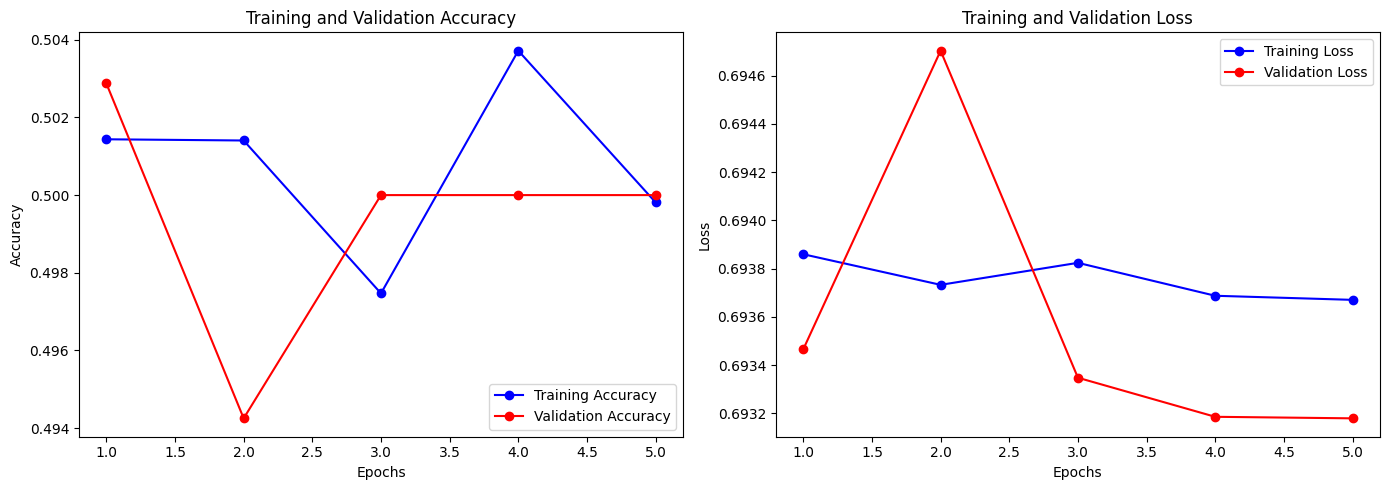

In [15]:
import matplotlib.pyplot as plt

# Access training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Create a figure with two subplots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation

### Subtask:
Evaluate the trained SimpleRNN model on the test set and generate detailed performance metrics.


**Reasoning**:
I will evaluate the model on the test set, calculate metrics, and visualize the confusion matrix to fulfill the subtask instructions.



Test Loss: 0.6931
Test Accuracy: 0.5039
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      4961
    Positive       0.50      1.00      0.67      5039

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.34     10000
weighted avg       0.25      0.50      0.34     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


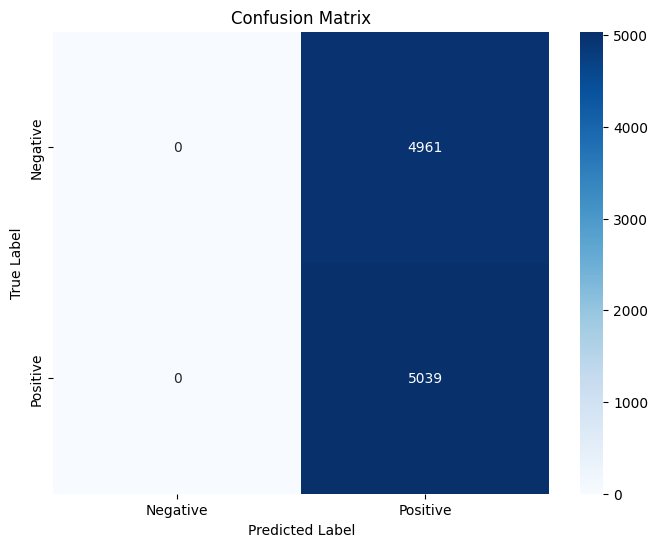

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1. Evaluate the model on test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 2. Generate predictions and convert to binary labels
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

# 4. Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 5. Compute and visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()